In [1]:
import easyMPRA_20231120 as em

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import hamming_loss


from _helper_functions import read_tsv
from _helper_functions import dprint
from _helper_functions import zipdf
from _helper_functions import cb
from _helper_functions import revcomp
from _helper_functions import load_pickle_dict

import pickle

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)



loading libraries...
done!


In [2]:
dnaMinRpmThresh=0.05 # do not consider any barcodes with RPM <.05
minDnaBc=5 # do not consider any enhancers with less than 5 barcodes per enhancer
minNumRepsDetectedRna=3 # to consider an enhancer in the analysis, require it is detected in at least 3 replicates
ratioAggFuncTuple2minActivityToCount={'mean':1.5} # require the enhancer has a minimum of 1.5 activity. anything below this is noise


# Load data

In [3]:

endf=pd.read_pickle(f'01-Barcode-Processing/endf.pd.df.pickle')


In [4]:
len(endf)

3318

In [5]:
endf.head(1)

,enhancer-seq,enhancer-id,barcode-seq,rpm-D1,rpm-D2,rpm-D3,rpm-D4,rpm-R1,rpm-R2,rpm-R3,rpm-R4,rpm-D5,rpm-D6,rpm-D7,rpm-R5,rpm-R6,rpm-R7
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAGATAAATACACAAATATCCTG,Chr8:6147080-6147146,"[TTGCTAACACGATTGCGGATCGATT, ACTTATCTACTGACTGTCCTCGCCT, TTTTGTATCAAGCTTGTGGGACCCG, GCTATGTTATCTGC...","[0.220733824144946, 0.23371713495616817, 0.15564169227966881, 0.4924309922433955, 0.038875310318...","[0.28989230073817873, 0.24411855465032495, 0.15240996659371667, 0.3197764512875319, 0.0304542638...","[0.2338136718273605, 0.37410018092653813, 0.14791915315194892, 0.35002404587412034, 0.0855597031...","[0.31803960026920236, 0.3066798448131834, 0.12480684722132872, 0.24939225940386225, 0.0906861328...","[nan, nan, nan, nan, nan, nan, 5.203892531585922, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[0.24875336076715374, 0.4168281875893575, 0.14103134625158528, 0.2751050225165744, 0.06038769179...","[0.2383559015027607, 0.33546243691143335, 0.1322768504744334, 0.387672671610621, 0.0792950626638...","[0.22696320104904208, 0.36313963813044275, 0.0680153362189268, 0.24917099864919873, 0.0377524809...","[nan, nan, nan, nan, nan, nan, nan, nan, 1.382970976254733, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, 9.650662663540787, nan, nan, nan, nan, nan]"


In [6]:
# this dictionary allows us to access the different samples in for loops
SampleScaffoldKey2ValueList={
    '{nt}':['R','D'],
    '{rep}':['1','2','3','4','5','6','7'],
}


# Filter out barcodes not detected in DNA

In [7]:


scaffold='rpm-{nt}{rep}'

for rep in SampleScaffoldKey2ValueList['{rep}']:
    
    print(rep)
    
    # without dna rpm min rilter
    dna=scaffold.replace('{nt}','D').replace('{rep}',rep)
    rna=scaffold.replace('{nt}','R').replace('{rep}',rep)
    
    endf[rna+'-filtNa-Dnotnull'],\
    endf[dna+'-filtNa-Dnotnull']=\
    em.filter_na_matched(indf=endf,
                         col1=rna,
                         col2=dna,
                         treatNaType={rna:'zero',dna:'omit'})
    
    # dna rpm min rilter

    endf[dna+f'-minDnaRpm{dnaMinRpmThresh}']=em.mask_na_filter(endf,dna,filterType='min',minVal=dnaMinRpmThresh)
    
    endf[rna+f'-minDnaRpm{dnaMinRpmThresh}'+'-filtNa-Dnotnull'],\
    endf[dna+f'-minDnaRpm{dnaMinRpmThresh}'+'-filtNa-Dnotnull']=\
    em.filter_na_matched(indf=endf,
                         col1=rna,
                         col2=dna+f'-minDnaRpm{dnaMinRpmThresh}',
                         treatNaType={rna:'zero',dna+f'-minDnaRpm{dnaMinRpmThresh}':'omit'})


1
2
3
4
5
6
7


# filter out any enhancers with <5 dna barcodes

In [8]:


scaffold = f'rpm-{{nt}}{{rep}}-minDnaRpm{dnaMinRpmThresh}-filtNa-Dnotnull'
    
for rep in SampleScaffoldKey2ValueList['{rep}']:

    print(rep)

    thisColDNA=scaffold.replace('{nt}','D').replace('{rep}',rep)
    thisColRNA=scaffold.replace('{nt}','R').replace('{rep}',rep)

    thisColDNAOut=thisColDNA+f'-minDnaBc{minDnaBc}'
    thisColRNAOut=thisColRNA+f'-minDnaBc{minDnaBc}'

    endf[thisColDNAOut]=endf.apply(lambda row: row[thisColDNA] if len(row[thisColDNA])>=minDnaBc else [],axis=1)
    endf[thisColRNAOut]=endf.apply(lambda row: row[thisColRNA] if len(row[thisColDNA])>=minDnaBc else [],axis=1)




1
2
3
4
5
6
7


In [11]:
def _opwrapper(l,func,omitna=True,null=np.NaN):
    # remove na if desired
    if omitna:    l=[li for li in l if not pd.isnull(li)]
    
    # 
    if len(l)>=1: return func(l)
    else:         return null

def _sum(l):
    return _opwrapper(l,func=sum,null=0)

def _max(l):
    return _opwrapper(l,func=max,null=0)

def _mean(l):
    return _opwrapper(l,func=np.mean,null=0)

In [12]:

# ratio 

aggfunc,agglabel=_mean,'mean' # aggregate within each rep by taking the mean of all RNA:DNA ratios, ignoring NA values

scaffold=f'rpm-{{nt}}{{rep}}' 
filtstyle=f'-minDnaRpm{dnaMinRpmThresh}-filtNa-Dnotnull-minDnaBc{minDnaBc}'
allRepsString='1234567'
        
# calculat reps individually
for rep in SampleScaffoldKey2ValueList['{rep}']:

    rna = scaffold.replace('{nt}','R').replace('{rep}',rep) + filtstyle
    dna = scaffold.replace('{nt}','D').replace('{rep}',rep) + filtstyle

    listcol=f'ratio-replist-{rep}{filtstyle}'

    endf[listcol] = \
    em.aggregate_matched_across_samples(indf=endf, 
                                        col1=rna, 
                                        col2=dna, 
                                        aggfunc=em.ratio)

    aggcol=f'ratio-repagg-{rep}{filtstyle}-{agglabel}'
    endf[aggcol] = \
    em.aggregate_within_samples(indf=endf,col=listcol,aggfunc=aggfunc)

# aggregate reps
minActivityToCount=ratioAggFuncTuple2minActivityToCount[agglabel]
expWideScaffold=f'ratio-repagg-{{rep}}{filtstyle}-{agglabel}'
colsToCombine=em.label_generator(expWideScaffold,SampleScaffoldKey2ValueList,'{rep}',endf.columns)

# takes sum of acitivity-wide replicate to get an expirement-wide activity score
allRepsString=''.join(SampleScaffoldKey2ValueList['{rep}'])
endf[f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}'] = em.concat_sample_values(endf,colsToCombine)
endf[f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}-minActFilt{minActivityToCount}'] = em.mask_na_filter(endf,f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}',minVal=minActivityToCount,filterType='min')


endf[f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}-minActFilt{minActivityToCount}-minRepsActObs{minNumRepsDetectedRna}-expsum'] = endf[f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}-minActFilt{minActivityToCount}'].apply(lambda l: sum    ([li for li in l if pd.notnull(li)]) if len([li for li in l if pd.notnull(li)])>=minNumRepsDetectedRna else np.NaN)

In [22]:
endf.head(1)

,enhancer-seq,enhancer-id,barcode-seq,rpm-D1,rpm-D2,rpm-D3,rpm-D4,rpm-R1,rpm-R2,rpm-R3,rpm-R4,rpm-D5,rpm-D6,rpm-D7,rpm-R5,rpm-R6,rpm-R7,rpm-R1-filtNa-Dnotnull,rpm-D1-filtNa-Dnotnull,rpm-D1-minDnaRpm0.05,rpm-R1-minDnaRpm0.05-filtNa-Dnotnull,rpm-D1-minDnaRpm0.05-filtNa-Dnotnull,rpm-R2-filtNa-Dnotnull,rpm-D2-filtNa-Dnotnull,rpm-D2-minDnaRpm0.05,rpm-R2-minDnaRpm0.05-filtNa-Dnotnull,rpm-D2-minDnaRpm0.05-filtNa-Dnotnull,rpm-R3-filtNa-Dnotnull,rpm-D3-filtNa-Dnotnull,rpm-D3-minDnaRpm0.05,rpm-R3-minDnaRpm0.05-filtNa-Dnotnull,rpm-D3-minDnaRpm0.05-filtNa-Dnotnull,rpm-R4-filtNa-Dnotnull,rpm-D4-filtNa-Dnotnull,rpm-D4-minDnaRpm0.05,rpm-R4-minDnaRpm0.05-filtNa-Dnotnull,rpm-D4-minDnaRpm0.05-filtNa-Dnotnull,rpm-R5-filtNa-Dnotnull,rpm-D5-filtNa-Dnotnull,rpm-D5-minDnaRpm0.05,rpm-R5-minDnaRpm0.05-filtNa-Dnotnull,rpm-D5-minDnaRpm0.05-filtNa-Dnotnull,rpm-R6-filtNa-Dnotnull,rpm-D6-filtNa-Dnotnull,rpm-D6-minDnaRpm0.05,rpm-R6-minDnaRpm0.05-filtNa-Dnotnull,rpm-D6-minDnaRpm0.05-filtNa-Dnotnull,rpm-R7-filtNa-Dnotnull,rpm-D7-filtNa-Dnotnull,rpm-D7-minDnaRpm0.05,rpm-R7-minDnaRpm0.05-filtNa-Dnotnull,rpm-D7-minDnaRpm0.05-filtNa-Dnotnull,rpm-D1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-replist-1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAGATAAATACACAAATATCCTG,Chr8:6147080-6147146,"[TTGCTAACACGATTGCGGATCGATT, ACTTATCTACTGACTGTCCTCGCCT, TTTTGTATCAAGCTTGTGGGACCCG, GCTATGTTATCTGC...","[0.220733824144946, 0.23371713495616817, 0.15564169227966881, 0.4924309922433955, 0.038875310318...","[0.28989230073817873, 0.24411855465032495, 0.15240996659371667, 0.3197764512875319, 0.0304542638...","[0.2338136718273605, 0.37410018092653813, 0.14791915315194892, 0.35002404587412034, 0.0855597031...","[0.31803960026920236, 0.3066798448131834, 0.12480684722132872, 0.24939225940386225, 0.0906861328...","[nan, nan, nan, nan, nan, nan, 5.203892531585922, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[0.24875336076715374, 0.4168281875893575, 0.14103134625158528, 0.2751050225165744, 0.06038769179...","[0.2383559015027607, 0.33546243691143335, 0.1322768504744334, 0.387672671610621, 0.0792950626638...","[0.22696320104904208, 0.36313963813044275, 0.0680153362189268, 0.24917099864919873, 0.03

# rescale activity so <0 is inert and >1 is active

In [23]:

# parameters
minRepsActObs=3 # enhancer must have detectable RNA activity in at least 3 reps
dnaMinRpmThresh=.05 # each barcode must be presetn >=.05 RPM in dna
minSumRnaSumDnaFilt=1.5 # each replicate activity must be higher than 1.5 in order to be counted. anything below this is too noisy
minDnaBc=5 # each enhancer must have >=5 dna barcodes within the replicate to be considered detected
pctlmin,pctlmax=(55,65) # rescale activity distribution so 0=55th percentile and 1=65th percentile
aggfunc1='mean' # take the mean of the RNA:DNA ratios within the replicate
aggfunc2='sum' # take the sum of all replicate activities to get the experiment-wide activity 


activityColFinal=f'ratio-expagg-1234567-minDnaRpm{dnaMinRpmThresh}-filtNa-Dnotnull-minDnaBc{minDnaBc}-{aggfunc1}-minActFilt{minSumRnaSumDnaFilt}-minRepsActObs{minRepsActObs}-exp{aggfunc2}'

# take the log2 of the activity before rescaling to the percentiles
endf[activityColFinal+'-log2']=endf[activityColFinal].apply(lambda a: np.log2(a) if a!=0 else np.NaN)


In [24]:
Func2Color={'Neural + Ectopic': cb['pink'],
 'Neural': cb['green'],
 'Inert': cb['orangenature'],
}

In [ ]:
# rescale based on dual cutoffs
activityColName=activityColFinal+'-log2'

activityName=activityColName

plotTitle=''

# thresholdToLabelPositives = None
thresholdToLabelPositives = np.percentile(endf[activityColName].dropna(), pctlmax)
thresholdToLabelNegatives = np.percentile(endf[activityColName].dropna(), pctlmin)

log2transformactivity=False
ymin,ymax=-5,3

printBadControls=False
plot_legend=False

subsampleviolin=False

scaling_range = thresholdToLabelPositives - thresholdToLabelNegatives
endf[activityColName+f'-rescaled-minpctl{pctlmin}-maxpctl{pctlmax}'] = endf[activityColName].apply(lambda a:(a - thresholdToLabelNegatives) / scaling_range)



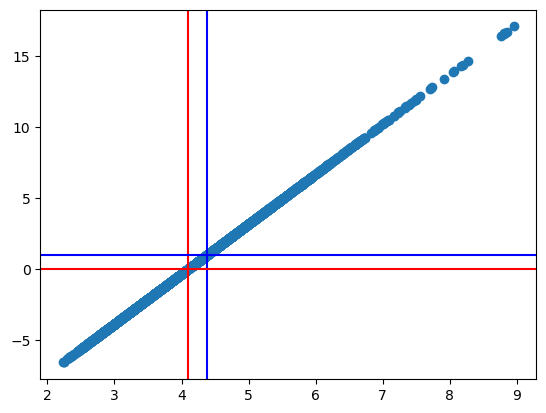

In [26]:
# show repro of rescaling

# show that the scaling is correct
fig,ax=plt.subplots(1)

ax.scatter(endf[activityColName],endf[activityColName+f'-rescaled-minpctl{pctlmin}-maxpctl{pctlmax}'])
ax.axvline(thresholdToLabelNegatives,color='red')
ax.axvline(thresholdToLabelPositives,color='blue')
ax.axhline(0,color='red')
ax.axhline(1,color='blue')

In [27]:
activityColName=activityColName+f'-rescaled-minpctl{pctlmin}-maxpctl{pctlmax}'


In [28]:
outcols=['enhancer-seq','enhancer-id','barcode-seq','ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65']


fn=f'01-Barcode-Processing/endf_final-experiment-enhancer-activity'
endf.to_pickle(fn+'.pd.df.pickle')
endf.to_csv(fn+'.tsv',sep='\t',index=None)